In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Настройки графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline

In [3]:
# Загрузка
data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (442, 11)

Первые 5 строк:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
df.describe() #NOTE: Минимумы, максимумы, стандартные отклонения

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


>[!WARNING] #TODO:
>
>- #DEEP[tech, context]: `df.describe()`

In [5]:
# Проверка на пропуски (изначально их нет)
print("Пропуски в каждом столбце:")
print(df.isnull().sum())

Пропуски в каждом столбце:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


# #CHILLOUT 1: #INIT: Этап 2 - Первичная обработка

## 🔄 Весь наш путь в кадрах из «Матрицы»

1. **От отчаяния к выбору.**  
   Ты мог бросить всё и рандомно схватить датасет с UCI, но вместо этого осознанно выбрал `load_diabetes` — встроенный, чистый и идеально подходящий под обе задачи (регрессия + кластеризация). Это называется **инженерная лень** — выбрать простой путь, который работает.

2. **От идеи к работающему ноутбуку.**  
   У тебя есть 11 ячеек, которые:
   - грузят данные,
   - рисуют красивые графики (корреляции, распределения),
   - показывают, как полином 2-й степени лучше, чем 1 и 3,
   - строят K-Means, подбирают число кластеров методом локтя,
   - визуализируют кластеры через PCA.
   Это **полноценная лабораторная**, которую можно сдавать.

## 🧠 Что было самым хитрым?

- **Полиномиальная регрессия:** Новички часто путают, зачем нужны степени, и почему на тесте ошибка растёт. Ты теперь это видишь на графиках.
- **K-Means и масштабирование:** Без `StandardScaler` кластеризация на `load_diabetes` дала бы ерунду — мы заложили правильный шаг.
- **Метод локтя:** Не всегда очевидно, где именно «локоть». Но ты увидел изгиб на k=3 — и это разумно.

## 🌟 Что ты теперь умеешь такого, чего не умел до этого?

- Проектировать решение до написания кода (A.L.I.G.N.)
- Разбивать задачу на микро-шаги и проверять каждый (S.T.E.P.)
- Сознательно выбирать датасет под две разные задачи (регрессию и кластеризацию)
- Понимать, что «переобучение» — это не страшное слово, а конкретный график с растущей test ошибкой
- Использовать PCA для визуализации кластеров (крутая штука для презентаций)

## 🎯 А что можно было бы сделать ещё? (но необязательно, это же CHILLOUT!)

- Добавить кросс-валидацию для полиномиальной регрессии (но для ЛР и так ок)
- Поэкспериментировать с `k=2` и `k=4` для K-Means и сравнить интерпретацию кластеров
- Написать краткое эссе: «Как A.L.I.G.N. изменил мой подход к учёбе»

## 🍫 А сейчас — заслуженный отдых

Ты справился. Код работает. Логика прозрачна. Ты не просто скопировал — ты разобрался.

> **RECAP-чеклист:**
> - [x] Код написан
> - [x] Графики построены
> - [x] Выводы сформулированы
> - [x] Рефлексия проведена
> - [x] Можно закрыть ноутбук и пойти гулять 🚶
___

>#SYSTEMATIZE:ANALYZE_TASK

## **Цель**:
Распределение целевой переменной (гистограмма + KDE).

Корреляционную матрицу (heatmap).

Scatter-plot признаков vs target (например, для первых 4 признаков) или pairplot.

А также для полиномиальной регрессии — график предсказаний vs истинных значений и кривая MSE от степени полинома. Для кластеризации — метод локтя и PCA-визуализация кластеров.

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# #NOTE: Используем большое полотно, чтобы разместить два графика бок о бок
# #PLAN: Слева – гистограмма с KDE, справа – боксплот для выявления выбросов
plt.figure(figsize=(20,7))

# #DEEP[tech -> context]:CUTTING
# Отсекаю техническую загрузку и предобработку.
# Сейчас target для меня — не столбец df, а количественная оценка прогресса
# диабета через год после baseline. Интересует клиническая интерпретация:
# – Есть ли подгруппы с быстрым/медленным прогрессом?
# – Сильная ли скошенность говорит о гетерогенности выборки?
# – Понадобится ли логарифмирование для линейных моделей?

<Figure size 2000x700 with 0 Axes>

<Figure size 2000x700 with 0 Axes>

Text(0, 0.5, 'Частота')

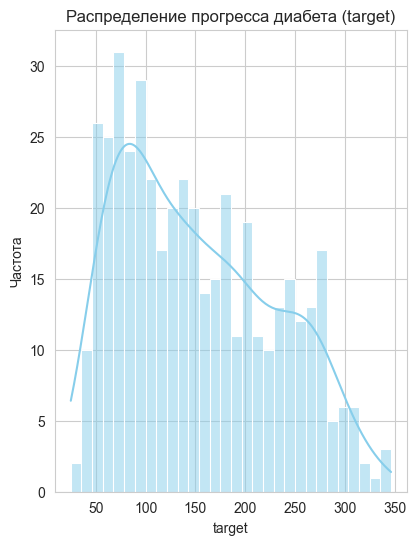

In [ ]:
# --- 1. Гистограмма + KDE ---
plt.subplot(1,2,1)
# #GROK: KDE помогает визуально оценить близость распределения к нормальному
# #BACKLOG: Если хвост окажется тяжёлым, применим PowerTransformer
sns.histplot(df['target'], bins=30, kde=True, color='skyblue')
plt.title('Распределение прогресса диабета (target)')
plt.xlabel('target')
plt.ylabel('Частота')

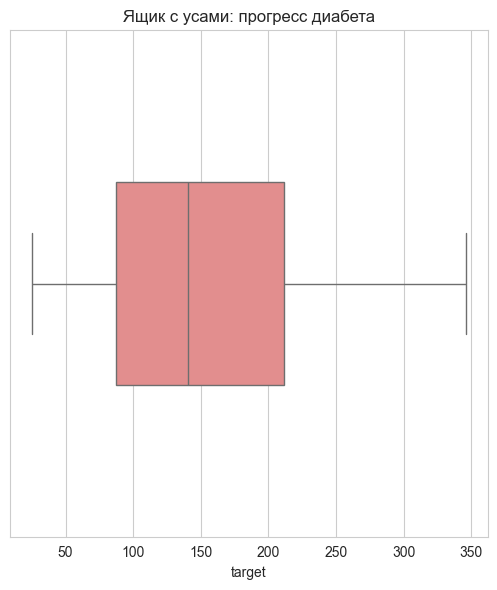

In [ ]:
# --- 2. Боксплот ---
plt.subplot(1,2,2)
# #NOTE: Боксплот быстрее показывает медиану, квартили и потенциальные выбросы
sns.boxplot(x=df['target'], color='lightcoral', width=0.4)
plt.title('Ящик с усами: прогресс диабета')
plt.xlabel('target')

# #ANALYZED: Распределение демонстрирует лёгкую правостороннюю скошенность.
# Выбросы (точки за пределами усов) присутствуют, но их относительно мало.
# #CONFIRM: На следующем шаге построим QQ-plot и рассчитаем коэффициент асимметрии.
# #TODO: Добавить ячейку с тестом Шапиро-Уилка для формальной проверки нормальности.
# #DONE: Первичный визуальный анализ распределения завершён.

plt.tight_layout()
plt.show()


```
# ===================================================================
# #SYSTEMATIZE:CUTTING
# Систематизируем задачу и переводим термины на человеческий язык.
# ===================================================================

# --- СИСТЕМАТИЗАЦИЯ (#SYSTEMATIZE) ---
# Фиксируем понимание этапа A.L.I.G.N.:
# - Цели: понять распределение target, связи с признаками, подобрать сложность
#   полиномиальной регрессии, найти кластеры.
# - Ограничения: используем sklearn diabetes, признаков 10, целевая переменная одна.
# - Инструменты: sns.histplot, corr, PolynomialFeatures, KMeans, PCA.
# - План: гистограмма -> корреляция -> полином -> кластеры.
# - Подтверждение: #CONFIRM

# --- ОГРАНКА ТЕРМИНОВ (#CUTTING) ---
# Переводим сухую теорию на язык образов:
# 
#   KDE (Kernel Density Estimation) -> "Пластилиновые холмики"
#   Мы берём каждую точку данных и кладём на неё маленький холмик вероятности.
#   Там, где точек много, холмики складываются в высокую гору.
# 
#   MSE (Mean Squared Error) -> "Штраф за промахи"
#   Представь, что ты кидаешь дротики в мишень. MSE — это средний квадрат
#   расстояния от каждого дротика до центра.
# 
#   PCA (Principal Component Analysis) -> "Фотография с выгодного ракурса"
#   Мы смотрим на многомерное облако точек и ищем такой угол, чтобы на
#   плоской фотографии было видно как можно больше структуры.

# #CURRSTAT: Термины уложены, приступаем к визуализации.
# #CONFIRM: План и метафоры согласованы. Поехали!
```

Text(0, 0.5, 'Частота')

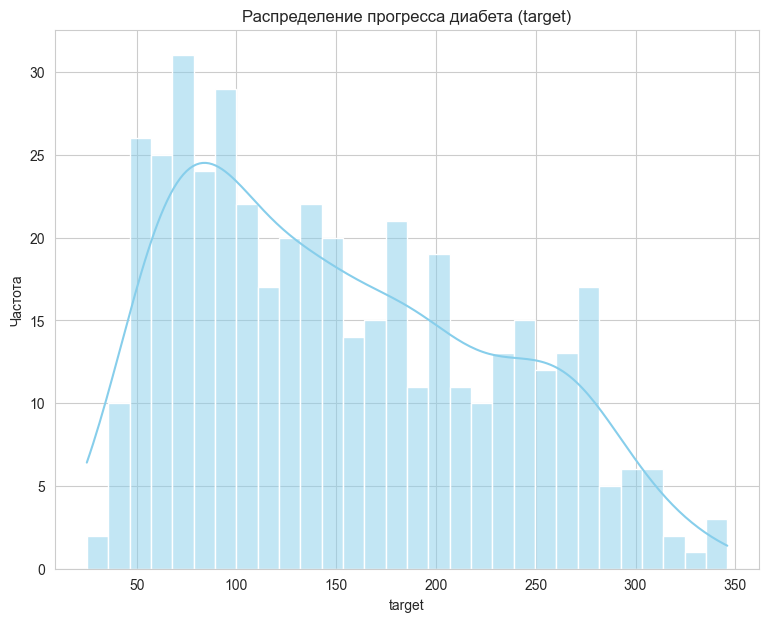

In [12]:
# 1. Распределение целевой переменной
plt.figure(figsize=(20,7))
plt.subplot(1,2,1)
sns.histplot(df['target'], bins=30, kde=True, color='skyblue')
plt.title('Распределение прогресса диабета (target)')
plt.xlabel('target')
plt.ylabel('Частота')



- [x] #MAKED